# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
data = pd.read_csv('tab_training.csv')
data_validation = pd.read_csv('tab_validation.csv')

data.head(), data_validation.head()

(   Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  1981      1  248.57  22.231935  106.048764
 1           2 -46.5 -23.5  1981      2  111.22  22.818929  101.649423
 2           3 -46.5 -23.5  1981      3  177.47  21.304839   93.651249
 3           4 -46.5 -23.5  1981      4  120.09  18.977667   67.507974
 4           5 -46.5 -23.5  1981      5   44.33  18.361613   61.594922,
    Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  2015      1  127.23  24.667742  128.816274
 1           2 -46.5 -23.5  2015      2  136.22  22.902500   98.479715
 2           3 -46.5 -23.5  2015      3  174.15  21.715806   92.170299
 3           4 -46.5 -23.5  2015      4   63.37  20.210667   71.118496
 4           5 -46.5 -23.5  2015      5   40.72  18.342903   55.356745)

# **Pre processing**

In [3]:
x1 = data[['lon','lat','year','month']]
x2 = data[['prec','temp']]
y = data['etp']

x1_vali= data_validation[['lon','lat','year','month']]
x2_validation = data_validation[['prec','temp']]
y_validation = data_validation['etp']

In [4]:
x2 = StandardScaler().fit_transform(x2)
x2 = pd.DataFrame(x2, columns=[data.columns[5:7]])
x2.head()

x2_validation = StandardScaler().fit_transform(x2_validation)
x2_validation = pd.DataFrame(x2_validation, columns=[data_validation.columns[5:7]])
x2_validation.head(),x2_validation.head()

(       prec      temp
 0  0.766078  0.275369
 1  0.891019 -0.175480
 2  1.418159 -0.478565
 3 -0.121429 -0.862984
 4 -0.436212 -1.340017,
        prec      temp
 0  0.766078  0.275369
 1  0.891019 -0.175480
 2  1.418159 -0.478565
 3 -0.121429 -0.862984
 4 -0.436212 -1.340017)

In [5]:
x = pd.concat([x1,x2],axis=1, join='inner')
x_validation = pd.concat([x1_vali,x2_validation],axis=1, join='inner')

x.head(),x_validation.head()

(    lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  1981      1  1.622619 -0.162164
 1 -46.5 -23.5  1981      2  0.215167 -0.020158
 2 -46.5 -23.5  1981      3  0.894044 -0.386449
 3 -46.5 -23.5  1981      4  0.306060 -0.949442
 4 -46.5 -23.5  1981      5 -0.470268 -1.098479,
     lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  2015      1  0.766078  0.275369
 1 -46.5 -23.5  2015      2  0.891019 -0.175480
 2 -46.5 -23.5  2015      3  1.418159 -0.478565
 3 -46.5 -23.5  2015      4 -0.121429 -0.862984
 4 -46.5 -23.5  2015      5 -0.436212 -1.340017)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=1)
x_train.to_csv('x_train.csv')
y_test.to_csv('y_test.csv')
y_train.to_csv('y_train.csv')
x_test.to_csv('x_test.csv')

# **Random Forest**

In [7]:
rf_model = rfs().fit(x_train, y_train)
             

## **Random Search param**

In [84]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 1000, num = 50)]
# Number of features to consider at every split
max_features = [1,2,3]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 5)]

hyperpar_space = {'max_depth':max_depth,
                  'n_estimators':n_estimators,
                  'max_features':max_features
                 }

rs_rf = RandomizedSearchCV(rf_model, param_distributions=hyperpar_space,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train, y_train)

In [9]:
hyperpar_space

{'max_depth': [1, 25, 50, 75, 100],
 'n_estimators': [50,
  69,
  88,
  108,
  127,
  146,
  166,
  185,
  205,
  224,
  243,
  263,
  282,
  302,
  321,
  340,
  360,
  379,
  398,
  418,
  437,
  457,
  476,
  495,
  515,
  534,
  554,
  573,
  592,
  612,
  631,
  651,
  670,
  689,
  709,
  728,
  747,
  767,
  786,
  806,
  825,
  844,
  864,
  883,
  903,
  922,
  941,
  961,
  980,
  1000],
 'max_features': [1, 2, 3]}

In [10]:
pd.DataFrame.from_dict(rs_rf.cv_results_).to_csv('random_Forest_iter.csv')
pd.DataFrame.from_dict(rs_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,29.797800,3.383576,7.046261,3.612590,534,1,100,"{'n_estimators': 534, 'max_features': 1, 'max_...",0.996966,0.997107,...,0.999544,0.999549,0.999540,0.999536,0.999548,0.999560,0.999558,0.999552,0.999549,8.065880e-06
1,17.570151,1.789420,0.646778,0.120359,398,1,50,"{'n_estimators': 398, 'max_features': 1, 'max_...",0.997068,0.997115,...,0.999546,0.999556,0.999542,0.999538,0.999526,0.999557,0.999537,0.999544,0.999544,8.823432e-06
2,49.004071,5.501524,29.198813,7.075992,806,1,50,"{'n_estimators': 806, 'max_features': 1, 'max_...",0.996982,0.997047,...,0.999564,0.999558,0.999543,0.999537,0.999570,0.999570,0.999536,0.999549,0.999554,1.202610e-05
3,91.171248,3.054604,20.411599,10.168240,980,3,75,"{'n_estimators': 980, 'max_features': 3, 'max_...",0.999601,0.999679,...,0.999942,0.999941,0.999944,0.999943,0.999942,0.999943,0.999941,0.999944,0.999943,1.182034e-06
4,8.001497,1.430770,0.321209,0.085711,825,2,1,"{'n_estimators': 825, 'max_features': 2, 'max_...",0.629732,0.637307,...,0.628321,0.620924,0.626822,0.626867,0.629760,0.627463,0.631109,0.625987,0.628573,3.841704e-03
5,26.720448,1.946463,0.830082,0.344583,360,2,100,"{'n_estimators': 360, 'max_features': 2, 'max_...",0.999351,0.999446,...,0.999904,0.999902,0.999905,0.999907,0.999907,0.999908,0.999905,0.999906,0.999905,2.416667e-06
6,21.515957,1.108347,0.468637,0.061602,282,3,25,"{'n_estimators': 282, 'max_features': 3, 'max_...",0.999592,0.999684,...,0.999941,0.999938,0.999939,0.999939,0.999940,0.999940,0.999941,0.999941,0.999940,7.904583e-07
7,6.578652,0.943415,0.220762,0.037746,709,2,1,"{'n_estimators': 709, 'max_features': 2, 'max_...",0.621217,0.628505,...,0.628691,0.619111,0.639124,0.616792,0.623836,0.625182,0.638046,0.630391,0.627193,6.868407e-03
8,61.673020,6.069099,13.691239,7.459279,728,3,75,"{'n_estimators': 728, 'max_features': 3, 'max_...",0.999609,0.999684,...,0.999942,0.999940,0.999942,0.999942,0.999942,0.999943,0.999941,0.999944,0.999942,1.064165e-06
9,5.720819,0.490181,0.221277,0.034525,728,2,1,"{'n_estimators': 728, 'max_features': 2, 'max_...",0.620226,0.620502,...,0.627232,0.617725,0.621247,0.616029,0.624133,0.618500,0.641084,0.628791,0.623685,6.981983e-03


<AxesSubplot:>

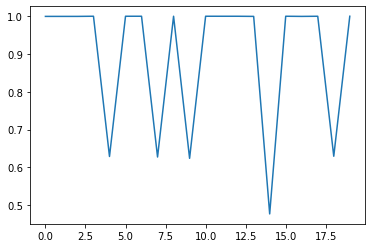

In [11]:
pd.DataFrame.from_dict(rs_rf.cv_results_)['mean_train_score'].plot()

In [85]:
print("Optimal hyperparameter combination:", rs_rf.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_rf.best_score_)
print()

Optimal hyperparameter combination: {'n_estimators': 980, 'max_features': 3, 'max_depth': 75}

Mean cross-validated training accuracy score: 0.9995851638384036



### ***Feature Importance***

In [13]:
importance = rs_rf.best_estimator_.feature_importances_
importance_graf = pd.DataFrame({'lon':[importance[0]],'lat':[importance[1]],
                                     'year':[importance[2]],'month':[importance[3]],
                                     'prec':[importance[4]], 'temp':[importance[5]]
                                })
importance_graf

,lon,lat,year,month,prec,temp
0,0.135602,0.108251,0.002167,0.089965,0.022772,0.641243


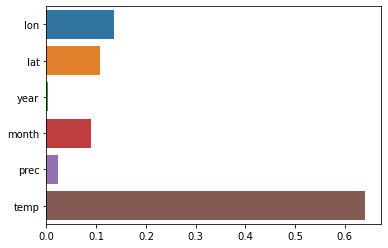

In [14]:
sns.barplot(data=importance_graf, orient='h');

## **Train**

In [15]:
yest_train = rs_rf.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('random_Forest_train_est.csv')

In [16]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
5794,91.480457,91.340866
17699,225.895266,225.519351
18803,176.613824,176.025690
20888,163.771120,163.769563
2133,71.273155,71.306800


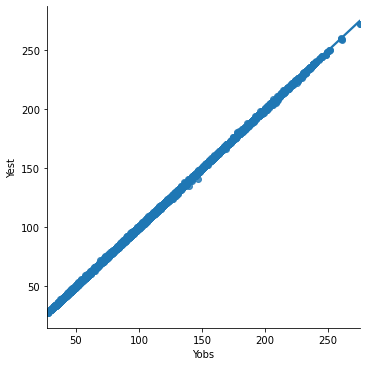

In [17]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [18]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
rf_mape = mape(y_train,yest_train)

r2,rmse,rrmse,rf_mape

(0.9999530947807959,
 0.29893888363009896,
 0.2822472905005982,
 0.16255664193443778)

findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.


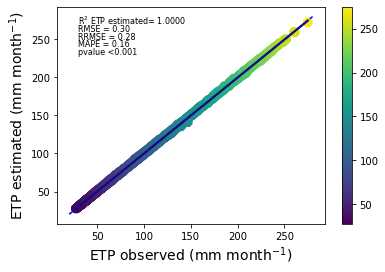

In [19]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

#plt.savefig('.png', transparent = False,bbox_inches='tight', dpi=1000)

## **Test**

In [20]:
yest_test = rs_rf.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('random_Forest_test_est.csv')

In [21]:
data = pd.DataFrame({'Yobs':y_test,
                         'Yest_rf': yest_test})

In [22]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
18017,65.865471,66.154954
16899,106.894505,108.349902
5472,123.731533,122.528556
19162,160.855627,161.057020
25986,104.609494,103.137315


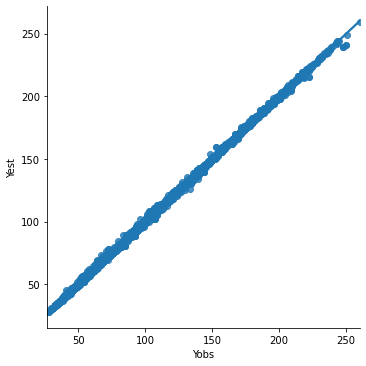

In [23]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [24]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
rf_mape = mape(y_test,yest_test)

r2,rmse,rrmse,rf_mape

(0.99968735835708, 0.7665576284524821, 0.7264252963369148, 0.4193849304902869)

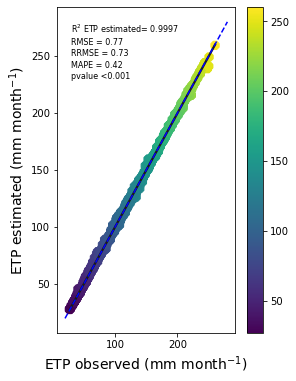

In [25]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('random_forest_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **StepWise** 

In [26]:
# checando
x_train.head(), y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 5794  -45.50 -23.25  1987     11  0.184016 -0.477776
 17699 -40.25  -8.00  1993     12 -0.770716  1.655368
 18803 -40.25  -7.25  1983     12 -0.635555  1.240512
 20888 -40.00  -7.25  1987      9 -0.811909  1.244705
 2133  -46.00 -23.50  1988     10  0.924683 -1.024029,
 5794      91.480457
 17699    225.895266
 18803    176.613824
 20888    163.771120
 2133      71.273155
 Name: etp, dtype: float64)

## **Train**

In [27]:
sw_model = LinearRegression()
sfs_model = sfs(sw_model,k_features=6, forward=True, scoring='r2',cv=10)
sfs_model=sfs_model.fit(x_train, y_train)
sfs_model.k_feature_names_

('lon', 'lat', 'year', 'month', ('prec',), ('temp',))

In [28]:
table = pd.DataFrame.from_dict(sfs_model.get_metric_dict()).T
table

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(5,)","[0.8640452473843615, 0.8656056653199596, 0.862...",0.865173,"((temp,),)",0.002372,0.003194,0.001065
2,"(1, 5)","[0.9010158579892459, 0.9039870231460361, 0.902...",0.901766,"(lat, (temp,))",0.001488,0.002004,0.000668
3,"(1, 3, 5)","[0.9169479862959702, 0.9179574029588828, 0.918...",0.916696,"(lat, month, (temp,))",0.001162,0.001564,0.000521
4,"(1, 3, 4, 5)","[0.9179206662720545, 0.918641509226899, 0.9188...",0.917524,"(lat, month, (prec,), (temp,))",0.001096,0.001475,0.000492
5,"(1, 2, 3, 4, 5)","[0.9190146600508077, 0.9194913879527022, 0.919...",0.918235,"(lat, year, month, (prec,), (temp,))",0.00104,0.0014,0.000467
6,"(0, 1, 2, 3, 4, 5)","[0.9191620653166389, 0.9196734812096157, 0.919...",0.918288,"(lon, lat, year, month, (prec,), (temp,))",0.001089,0.001466,0.000489


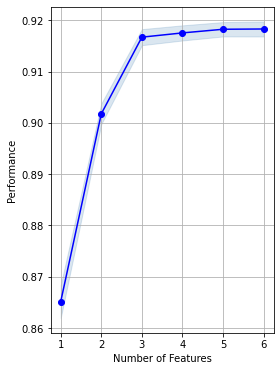

In [29]:
figure = plot_sfs(sfs_model.get_metric_dict(),kind='std_dev')
plt.grid()

In [30]:
table=table.sort_values('avg_score', ascending=False)['feature_names'].head(1)
table = table.tolist()
        
xobs_train = x_train[list(table[0][0:])]

xobs_train = sm.add_constant(xobs_train)
xobs_train.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


,const,lon,lat,year,month,"(prec,)","(temp,)"
5794,1.0,-45.50,-23.25,1987,11,0.184016,-0.477776
17699,1.0,-40.25,-8.00,1993,12,-0.770716,1.655368
18803,1.0,-40.25,-7.25,1983,12,-0.635555,1.240512
20888,1.0,-40.00,-7.25,1987,9,-0.811909,1.244705
2133,1.0,-46.00,-23.50,1988,10,0.924683,-1.024029


In [31]:
result = sm.OLS(y_train,xobs_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    etp   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 3.694e+04
Date:                Mon, 19 Feb 2024   Prob (F-statistic):               0.00
Time:                        10:51:11   Log-Likelihood:                -77686.
No. Observations:               19706   AIC:                         1.554e+05
Df Residuals:                   19699   BIC:                         1.554e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        334.8115     19.329     17.321      0.000     296.924     372.699
lon            0.6882      0.178      3.875      0.000       0.340       1.036
lat           -2.1697      0.069    -31.607      0.000      -2.304      -2.035
year          -0.1204      0.009    -13.217      0.000      -0.138      -0.103
month          1.4206      0.027     51.691      0.000       1.367       1.475
('prec',)     -1.5425      0.101    -15.265      0.000      -1.741      -1.344
('temp',)     51.7326      0.159    325.208      0.000      51.421      52.044
==============================================================================
Omnibus:                     1735.017   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2298.359
Skew:                           0.753   Prob(JB):                         0.00
Kurtosis:                       3.727   Cond. No.                     4.35e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.35e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
yest_train=result.fittedvalues
pd.DataFrame.from_dict(yest_train).to_csv('sw_train_est.csv')

In [33]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
5794,91.480457,105.382753
17699,225.895266,188.432388
18803,176.613824,166.338840
20888,163.771120,162.256424
2133,71.273155,74.638511


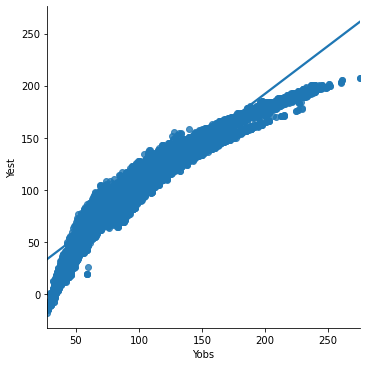

In [34]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [35]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train, yest_train)
rrmse = rmse*100/np.mean(y_train)
sw_mape = mape(y_train,yest_train)

r2,rmse,rrmse,sw_mape

(0.9183858787210688,
 12.469656147200858,
 11.773398690337531,
 11.306849234702115)

## **Test**

In [36]:
xobs_test = x_test[list(table[0][0:])]
xobs_test = sm.add_constant(xobs_test)
yest_test = result.predict(xobs_test)

pd.DataFrame.from_dict(yest_test).to_csv('sw_test_est.csv')
yest_test.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


18017     68.259419
16899    117.048597
5472     127.846104
19162    156.785413
25986    121.453258
dtype: float64

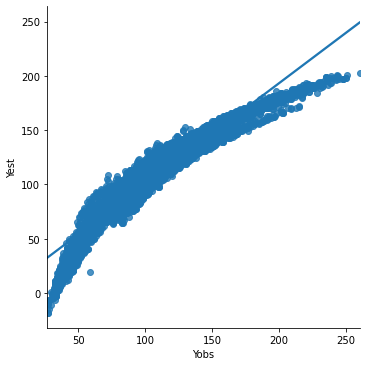

In [37]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [38]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
sw_mape = mape(y_test,yest_test)

r2,rmse,rrmse,sw_mape

(0.9189269339870376, 12.344107537892892, 11.697844549967119, 11.47404305100348)

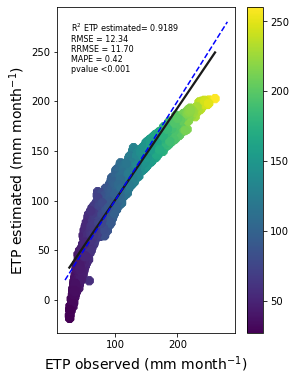

In [39]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('sw_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **MLP**

In [40]:
# checando 

x_train.head(),y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 5794  -45.50 -23.25  1987     11  0.184016 -0.477776
 17699 -40.25  -8.00  1993     12 -0.770716  1.655368
 18803 -40.25  -7.25  1983     12 -0.635555  1.240512
 20888 -40.00  -7.25  1987      9 -0.811909  1.244705
 2133  -46.00 -23.50  1988     10  0.924683 -1.024029,
 5794      91.480457
 17699    225.895266
 18803    176.613824
 20888    163.771120
 2133      71.273155
 Name: etp, dtype: float64)

In [41]:
mlp_model= MLPRegressor().fit(x_train,y_train)

## **Random Search param**

In [42]:
max_iter = [int(x) for x in np.linspace(start = 50, stop = 2050, num = 100)]
# Maximum number of levels in tree
alpha = [float(x) for x in np.arange(0.001, .3, 0.001)]
learning_rate_init = alpha


hyperpar_space_mlp = {'hidden_layer_sizes':[(5,5),(10,10),(10,5,10),(10,10,10),
                                           (50,10,50),(50,10,5),(5,10,100)],
                          'activation':['logistic','tanh','identity'],
                          'max_iter':max_iter,
                          'learning_rate_init': learning_rate_init,
                          'solver':['adam','sgd','lbfgs'],
                          'learning_rate':['constant', 'invscaling', 'adaptive'],
                          'alpha':alpha
                         }

In [43]:
rs_mlp = RandomizedSearchCV(mlp_model, param_distributions=hyperpar_space_mlp,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train,y_train)

C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: [-5.37964633e+10 -3.30903147e-04 -3.26895838e-04  9.15277677e-01
 -3.28584954e-04 -6.02768614e-04 -3.28663399e-04             nan
  9.16230304e-01             nan -6.67593787e-02 -9.91189325e-04
  9.16585018e-01  9.07993549e-01 -7.41921179e-04 -3.28663636e-04
 -7.31885536e-04  7.73757927e-01  1.48003664e-01 -3.28577988e-04]
  warnings.warn(
C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the train scores are non-finite: [-5.70611868e+10 -1.50835123e-08 -3.91150938e-08  9.15638189e-01
 -4.54147830e-13 -2.26874205e-04 -8.61949401e-11             nan
  9.16373178e-01             nan -7.12271719e-02 -3.56675135e-04
  9.16587352e-01  9.06826147e-01 -2.82339566e-04 -3.95587085e-10
 -3.15775081e-04  7.72731106e-01  1.49789294e-01  4.50017801e-13]
  warnings.warn(
C:\Users\luism\anaconda3\li

In [44]:
print("Optimal hyperparameter combination:", rs_mlp.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_mlp.best_score_)

Optimal hyperparameter combination: {'solver': 'lbfgs', 'max_iter': 494, 'learning_rate_init': 0.262, 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 10, 50), 'alpha': 0.192, 'activation': 'identity'}

Mean cross-validated training accuracy score: 0.9165850179889741


In [45]:
pd.DataFrame.from_dict(rs_mlp.cv_results_).to_csv('mlp_iter.csv')
pd.DataFrame.from_dict(rs_mlp.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_learning_rate,param_hidden_layer_sizes,param_alpha,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,59.419954,0.783726,0.006342,0.000714,sgd,555,0.138,invscaling,"(10, 5, 10)",0.204,...,-2.055171e+06,-2.305275e+05,-2.664889e+06,-5.706031e+11,-1.542427e+05,-1.958146e+06,-4.465824e+05,-4.946402e+05,-5.706119e+10,1.711806e+11
1,16.078301,2.691288,0.007180,0.001985,sgd,1140,0.143,adaptive,"(10, 10)",0.001,...,-1.347175e-08,-5.310892e-10,-7.514781e-08,-3.463507e-08,-3.129841e-09,-3.286383e-09,-1.654489e-08,-5.722800e-10,-1.508351e-08,2.249492e-08
2,10.577939,0.609903,0.005964,0.000362,sgd,130,0.236,adaptive,"(5, 5)",0.293,...,-1.029321e-10,-6.825246e-09,-5.830262e-08,-5.607517e-10,-1.038656e-07,-4.117427e-09,-1.311062e-08,-6.435354e-10,-3.911509e-08,4.476749e-08
3,12.188435,9.861650,0.005830,0.000705,lbfgs,1322,0.038,invscaling,"(10, 5, 10)",0.092,...,9.039956e-01,9.170818e-01,9.173703e-01,9.172305e-01,9.174837e-01,9.149871e-01,9.172272e-01,9.167993e-01,9.156382e-01,3.939216e-03
4,1.713576,0.328880,0.016066,0.000817,lbfgs,433,0.266,constant,"(50, 10, 50)",0.036,...,-3.486100e-14,8.537615e-14,-5.084821e-13,-2.886580e-15,-5.064615e-12,1.465605e-12,-2.462475e-13,-4.773959e-14,-4.541478e-13,1.615063e-12
5,2.853166,0.578298,0.007547,0.000461,adam,938,0.086,constant,"(10, 5, 10)",0.24,...,-6.834285e-05,-1.650339e-04,-2.800505e-04,-2.654405e-04,-4.978171e-04,-1.432928e-05,-4.119134e-05,-8.035536e-05,-2.268742e-04,2.203375e-04
6,1.671087,2.514162,0.007280,0.000779,lbfgs,1706,0.092,adaptive,"(10, 10, 10)",0.211,...,-9.505730e-13,-2.884359e-12,-2.174927e-12,-4.533929e-12,-9.590129e-11,-7.417467e-10,-5.011547e-13,-3.794520e-12,-8.619494e-11,2.202693e-10
7,26.420645,1.105629,0.026027,0.006990,sgd,151,0.124,adaptive,"(50, 10, 50)",0.126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,15.708464,8.587708,0.006613,0.001018,lbfgs,999,0.22,constant,"(10, 10, 10)",0.287,...,9.169946e-01,9.170222e-01,9.171412e-01,9.172096e-01,9.173017e-01,9.169949e-01,9.101286e-01,9.169195e-01,9.163732e-01,2.084499e-03
9,17.354105,0.830666,0.019154,0.006625,sgd,130,0.286,constant,"(5, 10, 100)",0.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(-1.0, 1.0)

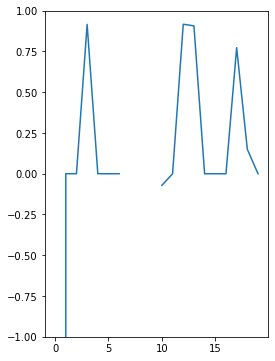

In [46]:
pd.DataFrame.from_dict(rs_mlp.cv_results_)['mean_train_score'].plot()
plt.ylim(-1,1)

## **Train**

In [47]:
yest_train = rs_mlp.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('mlp_train_est.csv')

In [48]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
5794,91.480457,104.432281
17699,225.895266,186.649764
18803,176.613824,164.613910
20888,163.771120,158.545480
2133,71.273155,78.044238


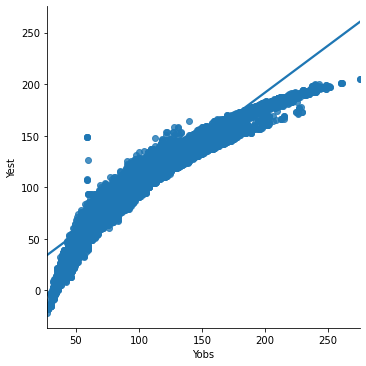

In [49]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [50]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
ann_mape = mape(y_train,yest_train)

r2,rmse,rrmse,ann_mape

(0.906097753173547, 13.375493520924522, 12.628657602336556, 12.320072013567918)

## **Test**

In [51]:
x_test.head(),y_test.head()

(         lon    lat  year  month   (prec,)   (temp,)
 18017 -40.25  -7.75  1986      6 -0.660763 -0.505355
 16899 -40.25  -8.50  1995      4 -0.051875  0.500313
 5472  -45.50 -23.50  1995      1  2.045111  0.294677
 19162 -40.25  -7.25  2013     11 -0.668449  1.152130
 25986 -39.25  -8.50  2004      7 -0.895424  0.485561,
 18017     65.865471
 16899    106.894505
 5472     123.731533
 19162    160.855627
 25986    104.609494
 Name: etp, dtype: float64)

In [52]:
yest_test = rs_mlp.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('mlp_test_est.csv')


In [53]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
18017,65.865471,66.671760
16899,106.894505,116.695420
5472,123.731533,130.307569
19162,160.855627,159.791535
25986,104.609494,120.354388


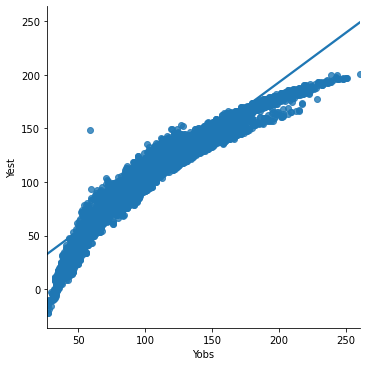

In [54]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [55]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
ann_mape = mape(y_test,yest_test)

r2,rmse,rrmse,ann_mape

(0.9074372013298633, 13.18984331158924, 12.499302701613683, 12.462225857586265)

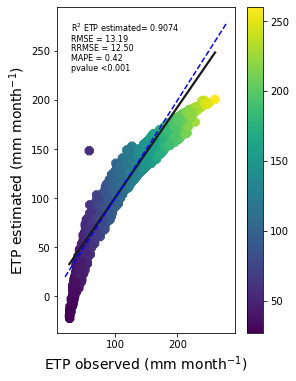

In [56]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('ann_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **General forecasting**

In [57]:
yest_validation = rs_rf.best_estimator_.predict(x_validation)

In [58]:
datagraf = pd.DataFrame({'Yobs':y_validation,
                         'Yest': yest_validation})
datagraf.head()

,Yobs,Yest
0,128.816274,120.843994
1,98.479715,96.741356
2,92.170299,89.018817
3,71.118496,69.197228
4,55.356745,52.029241


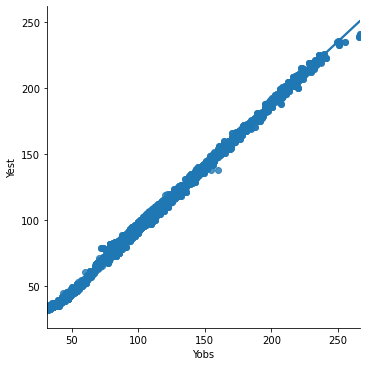

In [59]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [60]:
r2 = skm.r2_score(y_validation,yest_validation)
mse=skm.mean_squared_error(y_validation,yest_validation)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_validation, yest_validation)
rrmse = rmse*100/np.mean(y_validation)
rf_mape = mape(y_validation,yest_validation)



r2,rmse,rrmse, rf_mape

(0.974411900625604, 7.428535131630835, 6.612093386001537, 6.023457258258208)

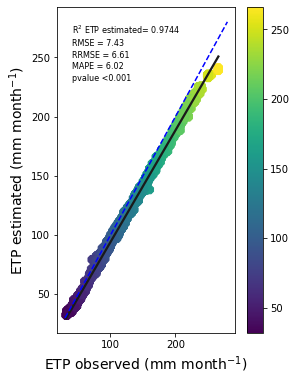

In [61]:
x=[30,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(40, 270, 'R$\mathregular{^{2}}$ ETP forecasted= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP forecasted (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('rf_validation.png', transparent = False,bbox_inches='tight', dpi=1000)

In [62]:
prec = data_validation['prec']
datagraf['prec']=prec
datagraf['et_obs']=datagraf['Yobs']
datagraf['et_est']=datagraf['Yest']
datagraf['year']=data_validation['year']
datagraf['month']=data_validation['month']

datagraf.to_csv('est_validiation.csv')

In [63]:
df15 = x_validation[(x_validation['year']==2015)]
df16= x_validation[(x_validation['year']==2016)]
df17= x_validation[(x_validation['year']==2017)]
df18= x_validation[(x_validation['year']==2018)]
df19= x_validation[(x_validation['year']==2019)]
df20= x_validation[(x_validation['year']==2020)]
df21= x_validation[(x_validation['year']==2021)]

In [64]:
y_15=y_validation[y_validation.index.isin(df15.index)]
y_16=y_validation[y_validation.index.isin(df16.index)]
y_17=y_validation[y_validation.index.isin(df17.index)]
y_18=y_validation[y_validation.index.isin(df18.index)]
y_19=y_validation[y_validation.index.isin(df19.index)]
y_20=y_validation[y_validation.index.isin(df20.index)]
y_21=y_validation[y_validation.index.isin(df21.index)]

In [65]:
yest_15 =rs_rf.best_estimator_.predict(df15)
datagraf = pd.DataFrame({'Yobs':y_15,
                         'Yest': yest_15})
r2 = skm.r2_score(y_15,yest_15)
mse=skm.mean_squared_error(y_15,yest_15)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_15, yest_15)
rrmse = rmse*100/np.mean(y_15)
rf_mape = mape(y_15,yest_15)



r2,rmse,rrmse, rf_mape

(0.9770651162918019, 7.629489225820892, 6.479978265452504, 5.101041355075815)

In [66]:
yest_16 =rs_rf.best_estimator_.predict(df16)
datagraf = pd.DataFrame({'Yobs':y_16,
                         'Yest': yest_16})
r2 = skm.r2_score(y_16,yest_16)
mse=skm.mean_squared_error(y_16,yest_16)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_16, yest_16)
rrmse = rmse*100/np.mean(y_16)
rf_mape = mape(y_16,yest_16)



r2,rmse,rrmse, rf_mape

(0.9753038121095003, 7.880311388759596, 6.726383511503692, 6.287671090333341)

In [67]:
yest_17 =rs_rf.best_estimator_.predict(df17)
datagraf = pd.DataFrame({'Yobs':y_17,
                         'Yest': yest_17})
r2 = skm.r2_score(y_17,yest_17)
mse=skm.mean_squared_error(y_17,yest_17)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_17, yest_17)
rrmse = rmse*100/np.mean(y_17)
rf_mape = mape(y_17,yest_17)



r2,rmse,rrmse, rf_mape

(0.9732148503069974, 7.4166617343852925, 6.755668849707003, 6.14158163804693)

In [68]:
yest_18 =rs_rf.best_estimator_.predict(df18)
datagraf = pd.DataFrame({'Yobs':y_18,
                         'Yest': yest_18})
r2 = skm.r2_score(y_18,yest_18)
mse=skm.mean_squared_error(y_18,yest_18)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_18, yest_18)
rrmse = rmse*100/np.mean(y_18)
rf_mape = mape(y_18,yest_18)



r2,rmse,rrmse, rf_mape

(0.9730519345472853, 7.173980001534262, 6.643230799930979, 6.62232230830803)

In [69]:
yest_19 =rs_rf.best_estimator_.predict(df19)

datagraf = pd.DataFrame({'Yobs':y_19,
                         'Yest': yest_19})
r2 = skm.r2_score(y_19,yest_19)
mse=skm.mean_squared_error(y_19,yest_19)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_19, yest_19)
rrmse = rmse*100/np.mean(y_19)
rf_mape = mape(y_19,yest_19)



r2,rmse,rrmse, rf_mape

(0.9772625845219439, 7.107714118268044, 6.27254990022513, 5.257899550479845)

In [70]:
yest_20 =rs_rf.best_estimator_.predict(df20)

datagraf = pd.DataFrame({'Yobs':y_20,
                         'Yest': yest_20})
r2 = skm.r2_score(y_20,yest_20)
mse=skm.mean_squared_error(y_20,yest_20)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_20, yest_20)
rrmse = rmse*100/np.mean(y_20)
rf_mape = mape(y_20,yest_20)



r2,rmse,rrmse, rf_mape

(0.9743120051283186, 7.100313603663185, 6.471414843206757, 6.066693816948412)

In [71]:
yest_21 =rs_rf.best_estimator_.predict(df21)
datagraf = pd.DataFrame({'Yobs':y_21,
                         'Yest': yest_21})
r2 = skm.r2_score(y_21,yest_21)
mse=skm.mean_squared_error(y_21,yest_21)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_21, yest_21)
rrmse = rmse*100/np.mean(y_21)
rf_mape = mape(y_21,yest_21)



r2,rmse,rrmse, rf_mape

(0.9675981617715679, 7.652882619005974, 6.911114760596378, 6.686991048615078)

# **stat**

In [72]:
from scipy import stats
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [73]:
data = pd.read_csv('tab_training.csv')
data[['etp']].describe().T

,count,mean,std,min,25%,50%,75%,max
etp,28152.0,105.797058,43.561438,26.905866,78.353517,98.583969,127.683605,274.871831


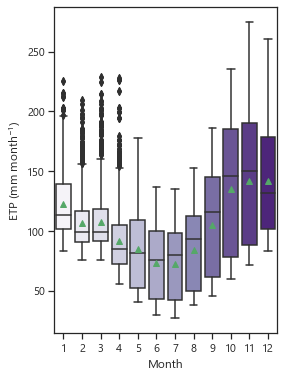

In [74]:
x = data[['etp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Purples',data=x, x= 'month',y='etp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('ETP (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('etpanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [75]:
data[['prec']].describe().T

,count,mean,std,min,25%,50%,75%,max
prec,28152.0,90.22235,97.589407,0.0,14.68,61.15,139.17,2494.39


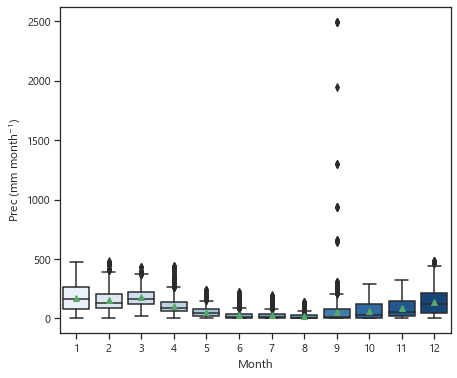

In [76]:
x = data[['prec','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Blues',data=x, x= 'month',y='prec' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Prec (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('prec.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [77]:
data[['temp']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,28152.0,22.902254,4.133646,11.486774,20.02129,23.487742,26.053336,31.290333


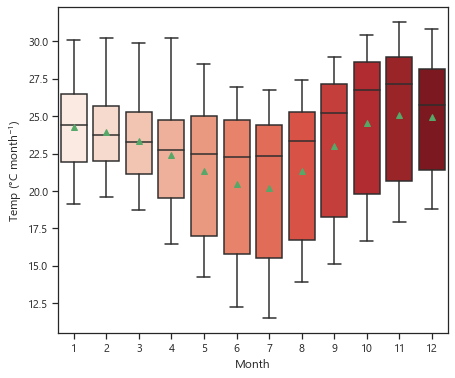

In [78]:
x = data[['temp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Reds',data=x, x= 'month',y='temp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Temp (°C month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('temp.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [79]:
data.groupby('month')[['etp']].describe()

etp                                                            \
        count        mean        std        min         25%         50%   
month                                                                     
1      2346.0  122.792200  27.309687  82.959736  101.442294  113.646476   
2      2346.0  107.029521  23.182400  75.903424   90.477444   99.261798   
3      2346.0  107.680616  24.186787  75.668494   91.382099   98.941297   
4      2346.0   92.024166  25.803784  55.637645   72.833486   85.263162   
5      2346.0   85.408064  34.257125  40.477811   52.573148   81.811116   
6      2346.0   73.112133  29.597799  29.823376   43.115121   76.137454   
7      2346.0   72.334963  29.051418  26.905866   42.563776   80.034769   
8      2346.0   84.265876  31.701690  38.305700   50.275956   93.719703   
9      2346.0  105.427838  41.586961  45.891025   61.704514  116.002809   
10     2346.0  135.002452  52.160135  59.590384   78.602553  146.046935   
11     2346.0  142.284960  53.185595  71.413953   88.156710  150.096811   
12     2346.0  142.201902  44.775992  83.159429  101.575413  132.132662   

                               
              75%         max  
month                          
1      139.581571  225.664649  
2      116.632666  209.791236  
3      118.869605  229.119524  
4      105.201120  228.400720  
5      109.194566  177.988341  
6      100.381729  136.596034  
7       98.403537  134.998921  
8      112.963959  152.719143  
9      145.041603  186.224434  
10     185.684575  235.463252  
11     190.013214  274.871831  
12     178.918732  260.914038

In [80]:
data.groupby('month')[['prec']].describe()

prec                                                             \
        count        mean         std    min       25%      50%      75%   
month                                                                      
1      2346.0  176.207003  106.641419   6.51   81.4900  165.550  262.740   
2      2346.0  151.697442   89.414613   2.37   86.4300  128.280  210.060   
3      2346.0  176.465767   75.776270  16.71  122.8000  165.465  222.430   
4      2346.0  107.662758   70.844399   1.38   59.2400   88.835  140.580   
5      2346.0   54.243333   42.369927   0.34   23.8225   44.540   77.240   
6      2346.0   28.042801   33.948293   0.12    6.6125   14.530   38.930   
7      2346.0   26.724672   31.796339   0.35    5.6825   14.135   36.795   
8      2346.0   18.121368   25.921952   0.00    1.3625    5.425   25.830   
9      2346.0   54.986824  148.360820   0.00    1.6600   10.910   81.905   
10     2346.0   65.068640   67.894433   0.00    6.3625   32.810  121.590   
11     2346.0   86.500422   75.225553   0.87   21.7200   51.650  146.990   
12     2346.0  136.947165   99.485350   1.14   44.6000  125.510  210.320   

                
           max  
month           
1       476.48  
2       481.27  
3       429.56  
4       439.42  
5       237.40  
6       221.34  
7       200.76  
8       137.10  
9      2494.39  
10      291.87  
11      320.45  
12      481.66

In [81]:
data.groupby('month')[['temp']].describe()

temp                                                        \
        count       mean       std        min        25%        50%   
month                                                                 
1      2346.0  24.299885  2.583861  19.102903  21.949919  24.440806   
2      2346.0  23.951190  2.298129  19.571071  21.991071  23.772377   
3      2346.0  23.317883  2.420940  18.724516  21.123871  23.291935   
4      2346.0  22.399369  2.960900  16.455667  19.556667  22.761667   
5      2346.0  21.318251  4.202583  14.260000  16.963548  22.478387   
6      2346.0  20.493999  4.511043  12.254333  15.771333  22.277333   
7      2346.0  20.212603  4.546969  11.486774  15.496694  22.354194   
8      2346.0  21.313083  4.283757  13.908387  16.736774  23.369677   
9      2346.0  22.993705  4.422845  15.155000  18.293250  25.235833   
10     2346.0  24.530001  4.374760  16.679355  19.776129  26.749677   
11     2346.0  25.072151  4.196985  17.952333  20.682333  27.122333   
12     2346.0  24.924924  3.488267  18.802903  21.408226  25.720323   

                             
             75%        max  
month                        
1      26.484194  30.073226  
2      25.685714  30.202414  
3      25.268065  29.892258  
4      24.751333  30.229667  
5      25.005645  28.491935  
6      24.739833  26.975667  
7      24.396694  26.740000  
8      25.253226  27.411935  
9      27.179500  28.938000  
10     28.612258  30.422903  
11     28.938667  31.290333  
12     28.147419  30.853871

In [82]:
data = pd.read_csv('climatology.csv')
data

,Unnamed: 0,station,month,prec,temp,etp,etr,def,exc,wb
0,1,-46.5_-23.5,1,259.720294,22.531414,108.124307,108.124307,0.000000,151.595987,151.595987
1,2,-46.5_-23.5,2,216.072941,22.700989,99.834259,99.834259,0.000000,116.238682,116.238682
2,3,-46.5_-23.5,3,189.636765,21.698330,96.255530,96.255530,0.000000,93.381235,93.381235
3,4,-46.5_-23.5,4,114.253529,20.090490,74.768964,74.768964,0.000000,39.484565,39.484565
4,5,-46.5_-23.5,5,90.216765,17.546366,54.990811,54.990811,0.000000,35.225954,35.225954
...,...,...,...,...,...,...,...,...,...,...
823,824,-39.25_-7.25,8,4.553824,25.954526,125.471652,13.918243,111.553409,0.000000,-111.553409
824,825,-39.25_-7.25,9,6.834412,27.809735,158.660604,9.945252,148.715351,0.000000,-148.715351
825,826,-39.25_-7.25,10,16.009118,28.997495,194.276542,16.735108,177.541434,0.000000,-177.541434
826,827,-39.25_-7.25,11,23.846765,29.153941,194.865289,23.967011,170.898277,0.000000,-170.898277


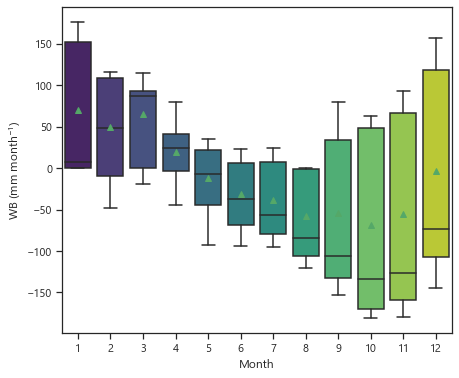

In [83]:
x = data[['wb','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='viridis',data=x, x= 'month',y='wb' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('WB (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('wdanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()